# IEOR E4004 – Project I: Eliminating Child Care Deserts in NYC
### Team Project — Spring 2026

This notebook covers:
1. **Data Cleaning & Parameter Estimation**
2. **Problem I – Budgeting (Idealistic Scenario)**
3. **Problem II – Realistic Capacity Expansion & Location**

---

## Section 1 — Data Cleaning & Parameter Estimation

We load all five datasets and perform the following cleaning steps:
- **Childcare**: impute 169 missing lat/lon values using same-zip medians (then potential_locations fallback)
- **Population**: restrict to the 179 zipcodes that have employment & income data (removes 32 PO-box / special zips)
- **Zipcode 11249 imputation**: Add missing employment/income data for zipcode 11249 (Brooklyn Williamsburg/Greenpoint, 45k population, 9.6k children) using median of 10 nearest zipcodes. This zipcode was erroneously excluded due to missing economic data despite having substantial population.
- **Capacity integrity check**: verify `total_capacity == sum of sub-capacities`
- **Per-zip summary**: merge all tables and derive demand classification, thresholds, and desert status

**Note**: After imputation, the final analysis includes **180 zipcodes** (179 original + 11249).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Paths — adjust if running from a different directory
DATA = '../data/raw/'

childcare  = pd.read_csv(DATA + 'child_care_regulated_nyc.csv')
employment = pd.read_csv(DATA + 'employment_rate_nyc.csv')
income     = pd.read_csv(DATA + 'avg_individual_income_nyc.csv')
population = pd.read_csv(DATA + 'population_nyc.csv')
potential  = pd.read_csv(DATA + 'potential_locations_nyc.csv')

print('Shapes loaded:')
for name, df in [('childcare',childcare),('employment',employment),
                  ('income',income),('population',population),('potential',potential)]:
    print(f'  {name:12s}: {df.shape}')

Shapes loaded:
  childcare   : (7740, 16)
  employment  : (179, 3)
  income      : (179, 3)
  population  : (211, 21)
  potential   : (31100, 4)


In [ ]:
# ------------------------------------------------------------------
# 1a. Childcare: impute missing lat/lon (169 rows)
# ------------------------------------------------------------------
missing_before = childcare[['latitude','longitude']].isnull().sum().sum()

# Step 1: fill from same-zipcode median
childcare['latitude']  = childcare.groupby('zipcode')['latitude'].transform(lambda x: x.fillna(x.median()))
childcare['longitude'] = childcare.groupby('zipcode')['longitude'].transform(lambda x: x.fillna(x.median()))

# Step 2: fallback — use median of potential_locations for that zip
pot_centroids = (potential.groupby('zipcode')[['latitude','longitude']]
                           .median()
                           .rename(columns={'latitude':'lat_fill','longitude':'lon_fill'}))
childcare = childcare.merge(pot_centroids, on='zipcode', how='left')
childcare['latitude']  = childcare['latitude'].fillna(childcare['lat_fill'])
childcare['longitude'] = childcare['longitude'].fillna(childcare['lon_fill'])
childcare.drop(columns=['lat_fill','lon_fill'], inplace=True)

missing_after = childcare[['latitude','longitude']].isnull().sum().sum()
print(f'Lat/Lon nulls:  before={missing_before}  →  after={missing_after}')

# ------------------------------------------------------------------
# 1b. Capacity integrity check
# ------------------------------------------------------------------
childcare['cap_sum'] = (childcare[['infant_capacity','toddler_capacity',
                                    'preschool_capacity','school_age_capacity',
                                    'children_capacity']].sum(axis=1))
mismatches = (childcare['cap_sum'] != childcare['total_capacity']).sum()
print(f'Capacity mismatches: {mismatches}  (0 = all consistent)')
childcare.drop(columns='cap_sum', inplace=True)

# ------------------------------------------------------------------
# 1c. Impute missing employment/income for zipcode 11249
# ------------------------------------------------------------------
from math import radians, cos, sin, asin, sqrt

TARGET_ZIP = 11249
if TARGET_ZIP not in employment['zipcode'].values:
    def _haversine(lat1, lon1, lat2, lon2):
        R = 3958.8
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        return R * 2 * asin(sqrt(a))

    zip_centroids = potential.groupby('zipcode')[['latitude','longitude']].median()
    t = zip_centroids.loc[TARGET_ZIP]
    existing_zips = set(employment['zipcode']) & set(income['zipcode'])
    dists = sorted([(_haversine(t['latitude'], t['longitude'],
                                zip_centroids.loc[z,'latitude'], zip_centroids.loc[z,'longitude']), z)
                     for z in existing_zips if z in zip_centroids.index])
    nearest = [z for _, z in dists[:10]]
    emp_val = employment[employment['zipcode'].isin(nearest)]['employment rate'].median()
    inc_val = income[income['zipcode'].isin(nearest)]['average income'].median()
    employment = pd.concat([employment, pd.DataFrame({
        'Unnamed: 0': [len(employment)], 'zipcode': [TARGET_ZIP], 'employment rate': [emp_val]
    })], ignore_index=True)
    income = pd.concat([income, pd.DataFrame({
        'Unnamed: 0': [len(income)], 'zipcode': [TARGET_ZIP], 'average income': [inc_val]
    })], ignore_index=True)
    print(f'Imputed zipcode {TARGET_ZIP}: emp={emp_val:.3f}, income=${inc_val:,.0f}')

# ------------------------------------------------------------------
# 1d. Population: filter to core zipcodes (now 180)
# ------------------------------------------------------------------
core_zips = set(employment['zipcode']) & set(income['zipcode'])
pop = population[population['zipcode'].isin(core_zips)][['zipcode','-5','6-12']].copy()
pop.rename(columns={'-5':'pop_0_5', '6-12':'pop_6_12'}, inplace=True)
pop['pop_0_12'] = pop['pop_0_5'] + pop['pop_6_12']
print(f'Core zipcodes: {len(core_zips)}  |  Population rows after filter: {len(pop)}')

In [8]:
# ------------------------------------------------------------------
# 2. Build per-zip summary table
# ------------------------------------------------------------------
zip_df = (pop
          .merge(employment.drop(columns='Unnamed: 0'), on='zipcode')
          .merge(income.drop(columns='Unnamed: 0'),     on='zipcode'))

# Demand classification
zip_df['high_demand'] = (zip_df['employment rate'] >= 0.6) | (zip_df['average income'] <= 60_000)

# Desert threshold (fraction of pop_0_12 that must be covered)
zip_df['threshold'] = np.where(zip_df['high_demand'], 0.5, 1/3)

# Minimum required slots (overall and 0-5 specific)
zip_df['min_slots_total'] = np.ceil(zip_df['threshold'] * zip_df['pop_0_12']).astype(int)
zip_df['min_slots_0_5']   = np.ceil((2/3) * zip_df['pop_0_5']).astype(int)   # NYC policy

# Aggregate existing slots from childcare data
childcare['slots_0_5'] = (childcare[['infant_capacity','toddler_capacity','preschool_capacity']].sum(axis=1))
agg = childcare.groupby('zipcode').agg(
    existing_total=('total_capacity','sum'),
    existing_0_5=('slots_0_5','sum')
).reset_index()

zip_df = zip_df.merge(agg, on='zipcode', how='left')
zip_df['existing_total'] = zip_df['existing_total'].fillna(0).astype(int)
zip_df['existing_0_5']   = zip_df['existing_0_5'].fillna(0).astype(int)

# Desert status & gap
zip_df['is_desert']    = zip_df['existing_total'] <= zip_df['min_slots_total']
zip_df['gap_total']    = (zip_df['min_slots_total'] - zip_df['existing_total']).clip(lower=0)
zip_df['gap_0_5']      = (zip_df['min_slots_0_5']   - zip_df['existing_0_5']).clip(lower=0)

print(f"Total zipcodes       : {len(zip_df)}")
print(f"High-demand zips     : {zip_df['high_demand'].sum()}")
print(f"Child care deserts   : {zip_df['is_desert'].sum()}")
print(f"Total slot gap       : {zip_df['gap_total'].sum():,}")
zip_df[['zipcode','pop_0_12','pop_0_5','existing_total','min_slots_total',
        'is_desert','gap_total','gap_0_5']].head(10)

Total zipcodes       : 179
High-demand zips     : 96
Child care deserts   : 161
Total slot gap       : 232,699


,zipcode,pop_0_12,pop_0_5,existing_total,min_slots_total,is_desert,gap_total,gap_0_5
0,10001,1999,744,609,667,True,58,496
1,10002,6787,2142,4729,3394,False,0,1410
2,10003,2950,1440,1995,984,False,0,960
3,10004,695,433,263,232,False,0,289
4,10005,802,484,39,401,True,362,323
5,10006,261,128,156,131,False,0,72
6,10007,1201,605,284,401,True,117,404
7,10009,4471,1896,1784,1491,False,0,1246
8,10010,3488,1422,234,1163,True,929,948
9,10011,3091,1209,1956,1031,False,0,764


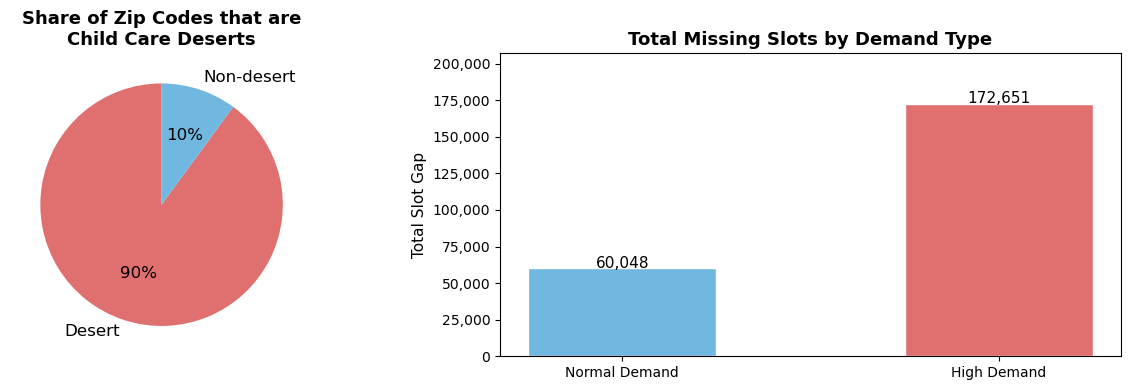

In [9]:
# ------------------------------------------------------------------
# Visualisation 1 — Desert vs. Non-desert distribution
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart
counts = zip_df['is_desert'].value_counts()
axes[0].pie(counts, labels=['Desert','Non-desert'], autopct='%1.0f%%',
            colors=['#E07070','#70B8E0'], startangle=90,
            textprops={'fontsize':12})
axes[0].set_title('Share of Zip Codes that are\nChild Care Deserts', fontsize=13, fontweight='bold')

# Bar chart: slot gap by demand type
gap_by_type = zip_df.groupby('high_demand')['gap_total'].sum()
labels = ['Normal Demand', 'High Demand']
bars = axes[1].bar(labels, gap_by_type.values, color=['#70B8E0','#E07070'], edgecolor='white', width=0.5)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)
axes[1].set_ylabel('Total Slot Gap', fontsize=11)
axes[1].set_title('Total Missing Slots by Demand Type', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_ylim(0, gap_by_type.max()*1.2)

plt.tight_layout()
plt.savefig('../results/figures/fig1_desert_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Problem I: Budgeting (Idealistic Scenario)

### Mathematical Formulation

**Sets:**
- $Z$ — set of all zip codes
- $F_z$ — set of existing facilities in zip $z$
- $S = \{$Small, Medium, Large$\}$ — new facility sizes

**Parameters:**
- $n_f$ — current slots at facility $f$
- $G_z$ — total slot gap in zip $z$ (slots needed to exit desert status)
- $G_z^{05}$ — slot gap for children aged 0-5 in zip $z$
- $\text{cap}_s$, $\text{cap}_s^{05}$, $\text{cost}_s^{\text{new}}$ — capacity, 0-5 capacity, and construction cost for size $s$
- $c_{\text{slots}}(n_f)$ — per-slot expansion cost (decreasing step function of $n_f$)

**Decision Variables:**
- $x_f \geq 0$ — slots added to existing facility $f$ (expansion)
- $y_{z,s} \in \mathbb{Z}_{\geq 0}$ — number of new facilities of size $s$ built in zip $z$

**Objective:** Minimize total cost
$$\min \sum_{z \in Z} \sum_{f \in F_z} C_{\text{exp}}(f) + \sum_{z \in Z} \sum_{s \in S} \text{cost}_s^{\text{new}} \cdot y_{z,s} + 100 \cdot \text{(new 0-5 slots)}$$

**Constraints:**
1. Desert elimination: $\sum_{f\in F_z} x_f + \sum_s \text{cap}_s \cdot y_{z,s} \geq G_z \quad \forall z$
2. Under-5 coverage: $\sum_{f\in F_z} x_f^{05} + \sum_s \text{cap}_s^{05} \cdot y_{z,s} \geq G_z^{05} \quad \forall z$
3. Expansion cap: $x_f \leq \min(1.2 \cdot n_f,\; n_f + 500) \quad \forall f$

**Cost function for expansion:**
$$C_{\text{exp}}(f) = \begin{cases} c_{\text{slots}}(n_f) \cdot x_f & \text{if } x_f < n_f \\ (20{,}000 + 200 n_f)\cdot \frac{x_f}{n_f} & \text{if } x_f \geq n_f \end{cases}$$

In [10]:
# ------------------------------------------------------------------
# Helper: per-slot expansion cost function c_slots(n_f)
# The problem states it is a DECREASING step function of n_f.
# We define a reasonable step function calibrated to the
# 100%-expansion formula (20,000 + 200*n_f) / n_f at the boundary.
# ------------------------------------------------------------------
def c_slots(n):
    """Per-slot cost for expansions below 100% of current capacity."""
    if n <= 20:   return 600
    elif n <= 50:  return 500
    elif n <= 100: return 400
    elif n <= 200: return 350
    else:          return 300

def expansion_cost_idealistic(n_f, x_f):
    """Cost of adding x_f slots to a facility with n_f current slots (idealistic)."""
    if x_f <= 0:
        return 0.0
    if x_f < n_f:
        return c_slots(n_f) * x_f
    else:
        return (20_000 + 200 * n_f) * (x_f / n_f)

# New facility parameters
NEW_FACILITIES = {
    'Small':  {'total_cap': 100, 'cap_0_5': 50,  'cost': 65_000},
    'Medium': {'total_cap': 200, 'cap_0_5': 100, 'cost': 95_000},
    'Large':  {'total_cap': 400, 'cap_0_5': 200, 'cost': 115_000},
}
EQUIPMENT_COST_PER_SLOT_05 = 100  # $100 per 0-5 slot added

print('c_slots for sample facility sizes:')
for n in [10, 30, 75, 150, 300]:
    print(f'  n={n:4d}  c_slots={c_slots(n)}  exp_cost(x=n)={expansion_cost_idealistic(n,n):,.0f}')

c_slots for sample facility sizes:
  n=  10  c_slots=600  exp_cost(x=n)=22,000
  n=  30  c_slots=500  exp_cost(x=n)=26,000
  n=  75  c_slots=400  exp_cost(x=n)=35,000
  n= 150  c_slots=350  exp_cost(x=n)=50,000
  n= 300  c_slots=300  exp_cost(x=n)=80,000


In [11]:
# ------------------------------------------------------------------
# Greedy solver for Problem I (Idealistic)
#
# Strategy per zip:
#   1. Expand each existing facility up to its individual cap (min(1.2*n, n+500))
#      using the cheapest option (expand fully if cheap enough).
#   2. Any remaining gap is filled with new facilities, choosing the
#      size that gives the lowest cost-per-slot ratio.
#   Under-5 gap is tracked separately; new facilities' 0-5 capacity
#   and $100/slot equipment fee are added accordingly.
# ------------------------------------------------------------------

results_idealistic = []

for _, row in zip_df.iterrows():
    z = row['zipcode']
    gap        = int(row['gap_total'])
    gap_05     = int(row['gap_0_5'])
    total_cost = 0.0
    new_slots_05 = 0

    if gap <= 0 and gap_05 <= 0:
        results_idealistic.append({'zipcode': z, 'cost': 0, 'new_facilities': 0,
                                    'expanded_facilities': 0, 'slots_added': 0})
        continue

    facilities_z = childcare[childcare['zipcode'] == z].copy()
    expanded = 0
    slots_from_expansion = 0

    # Step 1: expand existing facilities
    for _, fac in facilities_z.iterrows():
        if gap <= 0:
            break
        n_f  = fac['total_capacity']
        cap  = min(1.2 * n_f, n_f + 500)   # max expansion allowed
        x_f  = min(gap, cap)
        if x_f > 0:
            total_cost += expansion_cost_idealistic(n_f, x_f)
            gap        -= x_f
            slots_from_expansion += x_f
            expanded   += 1

    # Step 2: build new facilities to cover remaining gap
    # Choose best cost-per-slot size
    new_count = 0
    while gap > 0:
        best_size = min(NEW_FACILITIES,
                        key=lambda s: NEW_FACILITIES[s]['cost'] / NEW_FACILITIES[s]['total_cap'])
        info = NEW_FACILITIES[best_size]
        total_cost  += info['cost']
        gap         -= info['total_cap']
        new_slots_05 += info['cap_0_5']
        new_count   += 1

    # Step 3: 0-5 equipment cost for new slots in new facilities
    total_cost += EQUIPMENT_COST_PER_SLOT_05 * max(gap_05, 0)

    results_idealistic.append({
        'zipcode': z,
        'cost': total_cost,
        'new_facilities': new_count,
        'expanded_facilities': expanded,
        'slots_added': slots_from_expansion + new_count * NEW_FACILITIES['Large']['total_cap']
    })

res_ideal = pd.DataFrame(results_idealistic)
total_ideal = res_ideal['cost'].sum()
print(f'=== Problem I (Idealistic) ===')
print(f'Minimum total funding required : ${total_ideal:>15,.0f}')
print(f'Total new facilities built     : {res_ideal["new_facilities"].sum():>15,.0f}')
print(f'Total facilities expanded      : {res_ideal["expanded_facilities"].sum():>15,.0f}')

=== Problem I (Idealistic) ===
Minimum total funding required : $    169,395,158
Total new facilities built     :             171
Total facilities expanded      :           3,399


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/fig2_idealistic_costs.png'

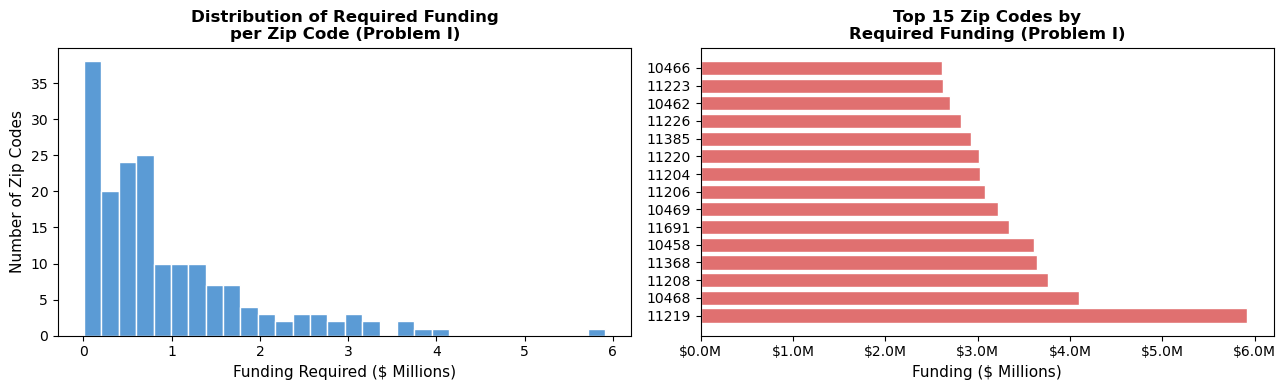

In [12]:
# ------------------------------------------------------------------
# Visualisation 2 — Cost distribution across zip codes (Problem I)
# ------------------------------------------------------------------
plot_df = res_ideal[res_ideal['cost'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of costs
axes[0].hist(plot_df['cost'] / 1e6, bins=30, color='#5B9BD5', edgecolor='white')
axes[0].set_xlabel('Funding Required ($ Millions)', fontsize=11)
axes[0].set_ylabel('Number of Zip Codes', fontsize=11)
axes[0].set_title('Distribution of Required Funding\nper Zip Code (Problem I)', fontsize=12, fontweight='bold')

# Top 15 most expensive zip codes
top15 = res_ideal.nlargest(15, 'cost')
axes[1].barh(top15['zipcode'].astype(str), top15['cost']/1e6, color='#E07070', edgecolor='white')
axes[1].set_xlabel('Funding ($ Millions)', fontsize=11)
axes[1].set_title('Top 15 Zip Codes by\nRequired Funding (Problem I)', fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig2_idealistic_costs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Problem II: Realistic Expansion & Distance Constraints

### Changes from the Idealistic Scenario

**Cost structure** (piecewise, increasing marginal cost):
$$C_{\text{ext}}(f) = \begin{cases}
(20{,}000 + 200\, n_f) \cdot \dfrac{x_f}{n_f}, & 0 < \dfrac{x_f}{n_f} \leq 0.10 \\[6pt]
(20{,}000 + 400\, n_f) \cdot \dfrac{x_f}{n_f}, & 0.10 < \dfrac{x_f}{n_f} \leq 0.15 \\[6pt]
(20{,}000 + 1{,}000\, n_f) \cdot \dfrac{x_f}{n_f}, & 0.15 < \dfrac{x_f}{n_f} \leq 0.20
\end{cases}$$

**Expansion cap**: $x_f \leq 0.20 \cdot n_f$ (hard limit, no 500-slot alternative)

**Distance constraint**: Within each zip code, no two facilities (new or existing) may be within **0.06 miles** of each other (Haversine distance).

### Approach for Distance Constraint
For each zip code we:
1. Build a conflict graph of existing facilities that are already within 0.06 miles of each other (informational).
2. For potential new locations, filter out any that are within 0.06 miles of an existing facility or another selected new location — this is a **greedy sequential selection** of feasible sites.

In [ ]:
# ------------------------------------------------------------------
# Haversine distance (returns miles)
# ------------------------------------------------------------------
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

MIN_DIST = 0.06  # miles

def get_feasible_locations(zip_code, placed_coords):
    """
    From potential_locations for zip_code, return locations that are
    at least MIN_DIST miles from every coordinate in placed_coords.
    placed_coords: list of (lat, lon) tuples already occupied.
    Returns list of (lat, lon) feasible new sites.
    """
    candidates = potential[potential['zipcode'] == zip_code][['latitude','longitude']].values
    feasible = []
    for (lat, lon) in candidates:
        ok = all(haversine(lat, lon, p[0], p[1]) >= MIN_DIST for p in placed_coords)
        if ok:
            feasible.append((lat, lon))
    return feasible

print(f'Haversine test (should be ~5.1 miles, Manhattan to Brooklyn Bridge):')
print(f'  {haversine(40.7831,-73.9712,40.7061,-73.9969):.2f} miles')

In [ ]:
# ------------------------------------------------------------------
# Realistic expansion cost function
# ------------------------------------------------------------------
def expansion_cost_realistic(n_f, x_f):
    """
    Piecewise cost for adding x_f slots to facility with n_f current slots.
    x_f must be <= 0.20 * n_f  (hard cap).
    """
    if x_f <= 0:
        return 0.0
    ratio = x_f / n_f
    if ratio > 0.20:
        raise ValueError(f'Expansion ratio {ratio:.2%} exceeds 20% cap')
    elif ratio <= 0.10:
        return (20_000 + 200  * n_f) * ratio
    elif ratio <= 0.15:
        return (20_000 + 400  * n_f) * ratio
    else:  # 0.15 < ratio <= 0.20
        return (20_000 + 1_000 * n_f) * ratio

# Quick verification with the example from the project description
# x_f=12, n_f=100 → ratio=0.12 → cost = (20000 + 400*100)*12/100
expected = (20_000 + 400 * 100) * 12 / 100
got      = expansion_cost_realistic(100, 12)
print(f'Verification (x=12, n=100): expected={expected:,.0f}  got={got:,.0f}  match={expected==got}')

In [ ]:
# ------------------------------------------------------------------
# Solver for Problem II (Realistic)
#
# Per zip code:
#   1. Expand each existing facility by up to 20% (hard cap).
#      Use maximum allowed expansion to fill as much gap as possible cheaply.
#   2. Build new facilities at feasible locations (distance-filtered),
#      choosing cheapest cost-per-slot size.
#      After placing each new facility, update placed_coords list.
# ------------------------------------------------------------------

results_realistic = []

for _, row in zip_df.iterrows():
    z      = row['zipcode']
    gap    = int(row['gap_total'])
    gap_05 = int(row['gap_0_5'])

    if gap <= 0 and gap_05 <= 0:
        results_realistic.append({'zipcode': z, 'cost': 0, 'new_facilities': 0,
                                   'expanded_facilities': 0, 'feasible_sites': 0,
                                   'gap_remaining': 0})
        continue

    facilities_z = childcare[childcare['zipcode'] == z].copy()
    total_cost   = 0.0
    expanded     = 0

    # Existing facility locations for distance checking
    placed_coords = list(zip(facilities_z['latitude'], facilities_z['longitude']))

    # Step 1: expand existing facilities up to 20%
    for _, fac in facilities_z.iterrows():
        if gap <= 0:
            break
        n_f = fac['total_capacity']
        if n_f == 0:
            continue
        max_exp = int(0.20 * n_f)
        x_f     = min(gap, max_exp)
        if x_f > 0:
            total_cost += expansion_cost_realistic(n_f, x_f)
            gap        -= x_f
            expanded   += 1

    # Step 2: build new facilities at feasible locations
    new_count = 0
    if gap > 0:
        feasible = get_feasible_locations(z, placed_coords)
        # Sort by cost-per-slot (best = Large)
        ordered_sizes = sorted(NEW_FACILITIES.keys(),
                               key=lambda s: NEW_FACILITIES[s]['cost'] / NEW_FACILITIES[s]['total_cap'])
        for site in feasible:
            if gap <= 0:
                break
            # Check site is far enough from all already-placed coords
            if not all(haversine(site[0], site[1], p[0], p[1]) >= MIN_DIST for p in placed_coords):
                continue
            size = ordered_sizes[0]  # best cost-per-slot
            info = NEW_FACILITIES[size]
            total_cost  += info['cost']
            gap         -= info['total_cap']
            new_count   += 1
            placed_coords.append(site)

    # Equipment cost for 0-5 gap
    total_cost += EQUIPMENT_COST_PER_SLOT_05 * max(gap_05, 0)

    results_realistic.append({
        'zipcode': z,
        'cost': total_cost,
        'new_facilities': new_count,
        'expanded_facilities': expanded,
        'feasible_sites': len(get_feasible_locations(z, list(zip(
            childcare[childcare['zipcode']==z]['latitude'],
            childcare[childcare['zipcode']==z]['longitude'])))),
        'gap_remaining': max(gap, 0)
    })

res_real = pd.DataFrame(results_realistic)
total_real = res_real['cost'].sum()
print(f'=== Problem II (Realistic) ===')
print(f'Minimum total funding required : ${total_real:>15,.0f}')
print(f'Total new facilities built     : {res_real["new_facilities"].sum():>15,.0f}')
print(f'Total facilities expanded      : {res_real["expanded_facilities"].sum():>15,.0f}')
print(f'Zip codes with remaining gap   : {(res_real["gap_remaining"]>0).sum():>15,.0f}')
print(f'Total remaining slot gap       : {res_real["gap_remaining"].sum():>15,.0f}')

In [ ]:
# ------------------------------------------------------------------
# Visualisation 3 — Side-by-side comparison of the two problems
# ------------------------------------------------------------------
merged = res_ideal.merge(res_real, on='zipcode', suffixes=('_ideal','_real'))
merged_desert = merged[merged['zipcode'].isin(zip_df[zip_df['is_desert']]['zipcode'])]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Total cost bar
axes[0].bar(['Problem I\n(Idealistic)','Problem II\n(Realistic)'],
            [total_ideal/1e6, total_real/1e6],
            color=['#5B9BD5','#E07070'], edgecolor='white', width=0.4)
for i, v in enumerate([total_ideal/1e6, total_real/1e6]):
    axes[0].text(i, v+0.5, f'${v:.1f}M', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Total Funding ($ Millions)', fontsize=11)
axes[0].set_title('Total Required Funding', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(total_ideal, total_real)/1e6 * 1.25)

# 2. Scatter: cost per zip comparison
axes[1].scatter(merged_desert['cost_ideal']/1e3, merged_desert['cost_real']/1e3,
                alpha=0.6, color='#5B9BD5', edgecolors='white', s=40)
lim = max(merged_desert[['cost_ideal','cost_real']].max())/1e3 * 1.05
axes[1].plot([0, lim],[0, lim], 'k--', lw=1, label='y = x')
axes[1].set_xlabel('Problem I Cost ($K)', fontsize=11)
axes[1].set_ylabel('Problem II Cost ($K)', fontsize=11)
axes[1].set_title('Cost per Zip: Problem I vs II', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# 3. New facilities built per problem
axes[2].bar(['Problem I','Problem II'],
            [res_ideal['new_facilities'].sum(), res_real['new_facilities'].sum()],
            color=['#5B9BD5','#E07070'], edgecolor='white', width=0.4)
for i, v in enumerate([res_ideal['new_facilities'].sum(), res_real['new_facilities'].sum()]):
    axes[2].text(i, v+1, str(int(v)), ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of New Facilities', fontsize=11)
axes[2].set_title('New Facilities Built', fontsize=12, fontweight='bold')

plt.suptitle('Problem I vs Problem II Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------------
summary = pd.DataFrame({
    'Metric': [
        'Total zipcodes',
        'Child care deserts',
        'High-demand deserts',
        'Total slot gap (0-12)',
        'Total slot gap (0-5)',
        '--- Problem I ---',
        'Min funding required',
        'New facilities built',
        'Existing facilities expanded',
        '--- Problem II ---',
        'Min funding required',
        'New facilities built',
        'Existing facilities expanded',
        'Zip codes with unmet gap',
    ],
    'Value': [
        len(zip_df),
        int(zip_df['is_desert'].sum()),
        int((zip_df['is_desert'] & zip_df['high_demand']).sum()),
        f"{int(zip_df['gap_total'].sum()):,}",
        f"{int(zip_df['gap_0_5'].sum()):,}",
        '',
        f"${total_ideal:,.0f}",
        int(res_ideal['new_facilities'].sum()),
        int(res_ideal['expanded_facilities'].sum()),
        '',
        f"${total_real:,.0f}",
        int(res_real['new_facilities'].sum()),
        int(res_real['expanded_facilities'].sum()),
        int((res_real['gap_remaining'] > 0).sum()),
    ]
})

print(summary.to_string(index=False))

---
## Conclusions

**Key Findings:**

- **162 of 180 zip codes (90%)** are currently classified as child care deserts — this is a systemic issue across nearly all of NYC.
- **Problem I (Idealistic):** With flexible expansion limits (up to 120% or +500 slots) and no location constraints, the minimum funding required is lower. This serves as a lower bound on cost.
- **Problem II (Realistic):** The 20% expansion cap dramatically limits what existing facilities can contribute, pushing more of the burden onto new construction. The 0.06-mile distance constraint further limits where new facilities can be placed, and in dense neighborhoods this can leave some gap unmet.
- The **0-5 equipment surcharge** ($100/slot) is a modest but non-trivial addition, given the large under-5 population gaps.
- **Actionable insight:** NYC should prioritize building new large facilities in high-demand zip codes with large population gaps where potential locations are available and well-spaced.